# Four-target SFP: exact start vs Gaussian initialization

本文件只评估已有的 **无选择器 single / multi 模型**，不会训练或改写模型。
使用原来的 Python / PyTorch 环境，把 notebook 放在仓库内，从上到下运行。

默认：已有的 10,000 epoch、seed 0；全部 1,000 个验证布局；精确起点每布局 1 条，
随机起点每布局 32 条；float64 RK4 1,000 步。主成功半径 0.02，辅助半径 0.05。
**这里的 10,000 是读取 checkpoint 的训练预算，不会再训练 10,000 epoch。**

固定布局条件 c 和名义起点 s，仅设置 a(0)=s+sigma*epsilon。每条轨迹只采样一次噪声，
后续积分不重新加噪声。single / multi、各训练 seed 使用相同扰动；不挑最佳样本。
matched Gaussian 的 sigma 从 checkpoint 读取，预期为原始坐标尺度 0.05。

主结果是从扰动后起点出发的采样表现，不能直接称为精确物理起点下的表现。
同时记录 s 到 a(0) 的偏移、加上连接段后的几何长度与覆盖率；连接段只是辅助核算，
并非 SFP 生成的动作，也没有为它安排额外执行时间。

参考：SFP Eq. (1) 与初始高斯分布；https://arxiv.org/html/2505.21851v2
随机初始化提供多样性，但不保证完整轨迹的联合分布或全目标覆盖。


In [1]:
from pathlib import Path
import hashlib, itertools, json, os, platform, time, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display

# Usually only PROJECT_ROOT_OVERRIDE needs changing when the notebook is outside the repo.
PROJECT_ROOT_OVERRIDE = None  # Example: Path(r'D:/projects/streaming-flow-policy')
TRAINING_EXPERIMENT_TAG = 'single_vs_multi_05pct_v1'
MULTIROUTE_FOLDER = 'v2_nearopt_05pct'
BUDGETS = [10000]             # Existing completed training budgets, NOT new training.
SEEDS = [0]                   # Existing paired training seeds.
NUM_NOISE_SAMPLES = 32
NOISE_SEED = 20260930         # Evaluation RNG; independent of training seed.
EXTRA_INIT_SIGMAS = []        # Optional prespecified sensitivity runs, e.g. [0.01, 0.025].
EVAL_STEPS = 1000
EVAL_BATCH_SIZE = 256         # Lower this if GPU memory is limited; cache separates settings.
VISIT_TOLERANCES = [0.02, 0.05]
NEAROPT_SLACK = 0.05
MAX_LAYOUTS = None           # None = all 1,000; e.g. 100 = diagnostic prefix only.
FIXED_PLOT_LAYOUTS = [12, 20, 281, 954]
PLOT_SEED = SEEDS[0]          # Chosen before looking at success.
SAVE_ALL_PATHS = False       # False keeps full-resolution paths only for fixed plot layouts.
OUTPUT_TAG = 'start_noise_sampling_v1'
IMPLEMENTATION_VERSION = 'start_noise_eval_v1.0'  # Bump if editing metric/integration logic.

# Optional exact paths if your checkpoint folders differ. Relative paths are repo-relative.
CHECKPOINT_OVERRIDES = {
    # (10000, 0, 'single'): Path(r'D:/.../single/final.pt'),
    # (10000, 0, 'multi'): Path(r'D:/.../multi/final.pt'),
}

def find_project_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        return Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
    here = Path.cwd().resolve()
    for root in [here, *here.parents]:
        if (root/'experiments/four_boxes_experiments/four_targets/datasets/v1/validation.npz').is_file():
            return root
    raise FileNotFoundError('Set PROJECT_ROOT_OVERRIDE to your streaming-flow-policy repository.')

assert BUDGETS and SEEDS and len(set(BUDGETS)) == len(BUDGETS) and len(set(SEEDS)) == len(SEEDS)
assert all(isinstance(x, int) and x > 0 for x in BUDGETS)
assert all(isinstance(x, int) and x >= 0 for x in SEEDS)
assert NUM_NOISE_SAMPLES >= 2 and EVAL_STEPS > 0 and EVAL_BATCH_SIZE > 0 and NOISE_SEED >= 0
assert len(set(VISIT_TOLERANCES)) == len(VISIT_TOLERANCES) and min(VISIT_TOLERANCES) > 0
assert 0.02 in VISIT_TOLERANCES and 0.05 in VISIT_TOLERANCES and PLOT_SEED in SEEDS
assert all(np.isfinite(s) and s > 0 for s in EXTRA_INIT_SIGMAS)
PROJECT_ROOT = find_project_root()
TASK_ROOT = PROJECT_ROOT/'experiments/four_boxes_experiments/four_targets'
V1_DIR = TASK_ROOT/'datasets/v1'
MULTI_DIR = TASK_ROOT/'datasets'/MULTIROUTE_FOLDER
TRAINING_ROOT = TASK_ROOT/'runs'/TRAINING_EXPERIMENT_TAG
OUTPUT_ROOT = TASK_ROOT/'evaluations'/OUTPUT_TAG
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float64
MODES = ['single', 'multi']
GAP_LABELS = ['<1%', '1-<5%', '5-<10%', '>=10%']
PERMS = np.asarray(list(itertools.permutations(range(4))), dtype=np.int64)
ORDER_CLASS = {tuple(p): i for i, p in enumerate(PERMS)}
print('Evaluation only. No optimizer, training, or selector is used.')
print('Project:', PROJECT_ROOT, '\nDevice:', DEVICE, '\nOutput:', OUTPUT_ROOT)
if DEVICE.type == 'cpu':
    print('CUDA unavailable: check the notebook kernel if you expect GPU inference.')


Evaluation only. No optimizer, training, or selector is used.
Project: /home/matcho/projects/streaming-flow-policy 
Device: cuda 
Output: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/evaluations/start_noise_sampling_v1


## 1. Validate data and completed checkpoints
自动寻找旧 single/multi 训练 notebook 的 `final.pt`；single 也支持更早的原始基线文件夹。
核对 epoch、训练 seed、预处理、架构和数据哈希。不会把选择器实验的路线条件模型当作基线。
文件夹找不到时，按报错设置开头的 `CHECKPOINT_OVERRIDES`；不会自动新建或重训模型。


In [2]:
def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024*1024), b''):
            h.update(block)
    return h.hexdigest()

def digest_json(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, allow_nan=False).encode()).hexdigest()

def atomic_json(value, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name+'.tmp')
    tmp.write_text(json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
    os.replace(tmp, path)

def atomic_csv(frame, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name+'.tmp')
    frame.to_csv(tmp, index=False, float_format='%.17g')
    os.replace(tmp, path)

def atomic_npz(path, **arrays):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name+'.tmp')
    with tmp.open('wb') as f:
        np.savez_compressed(f, **arrays)
    os.replace(tmp, path)

def route_lengths(start, targets):
    ordered = targets[PERMS]
    return (np.linalg.norm(ordered[:, 0]-start, axis=1)
            + np.linalg.norm(np.diff(ordered, axis=1), axis=2).sum(axis=1))

def gap_label(gap):
    return GAP_LABELS[int(np.searchsorted([1., 5., 10.], gap, side='right'))]

with np.load(V1_DIR/'validation.npz', allow_pickle=False) as z:
    VAL = {k: z[k].copy() for k in z.files}
N_VAL = len(VAL['targets'])
if N_VAL != 1000:
    raise ValueError(f'Expected original 1,000 validation layouts, got {N_VAL}.')
for name, shape in dict(starts=(N_VAL,2), targets=(N_VAL,4,2), conditions=(N_VAL,10),
                        routes=(N_VAL,5,2), lengths=(N_VAL,)).items():
    if VAL[name].shape != shape or not np.isfinite(VAL[name]).all():
        raise ValueError(f'Invalid validation array: {name}')
np.testing.assert_array_equal(VAL['conditions'], np.concatenate(
    [VAL['starts'], VAL['targets'].reshape(N_VAL,8)], axis=1))
np.testing.assert_allclose(VAL['routes'][:,0], VAL['starts'], rtol=0, atol=1e-7)
np.testing.assert_allclose(VAL['starts'], np.broadcast_to(VAL['starts'][0], (N_VAL,2)))
ALL_LENGTHS = np.stack([route_lengths(s,t) for s,t in zip(VAL['starts'], VAL['targets'])])
SORTED_LENGTHS = np.sort(ALL_LENGTHS, axis=1)
OPTIMAL = SORTED_LENGTHS[:,0]
if np.any(OPTIMAL <= 0):
    raise ValueError('Non-positive optimal route length.')
GAPS = 100*(SORTED_LENGTHS[:,1]-OPTIMAL)/OPTIMAL
N_AVAILABLE_NEAROPT = (ALL_LENGTHS <= (1+NEAROPT_SLACK)*OPTIMAL[:,None]+1e-10).sum(axis=1)
np.testing.assert_allclose(VAL['lengths'], OPTIMAL, rtol=2e-6, atol=1e-7)
DATA_HASHES = {name: sha256_file(V1_DIR/name) for name in ['train.npz','validation.npz']}
MULTI_HASH = sha256_file(MULTI_DIR/'train.npz')
build_config = json.loads((MULTI_DIR/'config.json').read_text(encoding='utf-8'))
if (build_config['source_train_sha256'] != DATA_HASHES['train.npz']
        or build_config['artifact_sha256']['train.npz'] != MULTI_HASH
        or not np.isclose(build_config['relative_slack'], NEAROPT_SLACK, rtol=0, atol=1e-12)):
    raise ValueError('Multi dataset provenance/slack mismatch. Use the original paired datasets.')
if MAX_LAYOUTS is not None and not (isinstance(MAX_LAYOUTS, int) and 1 <= MAX_LAYOUTS <= N_VAL):
    raise ValueError('MAX_LAYOUTS must be None or an integer between 1 and 1000.')
LAYOUT_IDS = np.arange(N_VAL if MAX_LAYOUTS is None else MAX_LAYOUTS, dtype=np.int64)
PLOT_IDS = [i for i in FIXED_PLOT_LAYOUTS if i in set(LAYOUT_IDS.tolist())]

def canonicalize_box_inputs(inputs):
    boxes = inputs[:,5:].reshape(-1,4,2)
    for coordinate in [1,0]:
        order = torch.argsort(boxes[:,:,coordinate], dim=1, stable=True)
        boxes = torch.gather(boxes, 1, order.unsqueeze(-1).expand(-1,-1,2))
    return torch.cat([inputs[:,:5], boxes.reshape(-1,8)], dim=1)

class CanonicalConditionalVelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []; width = 13
        for _ in range(4):
            layers.extend([nn.Linear(width,128), nn.SiLU()]); width = 128
        layers.append(nn.Linear(width,2))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(2.0*canonicalize_box_inputs(inputs)-1.0)

def checkpoint_path(budget, seed, mode):
    key = (budget,seed,mode)
    if key in CHECKPOINT_OVERRIDES:
        p = Path(CHECKPOINT_OVERRIDES[key]).expanduser()
        p = p if p.is_absolute() else PROJECT_ROOT/p
        if not p.is_file():
            raise FileNotFoundError(p)
        return p.resolve()
    candidates = [TRAINING_ROOT/f'budget_{budget}_seed_{seed}_{mode}'/'final.pt']
    if mode == 'single':
        old = TASK_ROOT/'runs/conditional_mlp_canonical_seed_sweep'/f'budget_{budget}_seed_{seed}'
        candidates.extend([old/'final.pt', old/'latest.pt'])
        if seed == 0:
            old = TASK_ROOT/'runs'/f'conditional_mlp_canonical_{budget}epochs_v1_seed0'
            candidates.extend([old/'final.pt', old/'latest.pt'])
    for p in candidates:
        if p.is_file():
            return p
    raise FileNotFoundError(f'No completed {key} checkpoint. Set CHECKPOINT_OVERRIDES. Tried: '
                            + ', '.join(map(str,candidates)))

EXPECTED_ARCH = dict(input_preprocessing='sort_targets_by_x_then_y', hidden_dim=128, num_hidden_layers=4)
RECORDS = {}
for budget in BUDGETS:
    for seed in SEEDS:
        for mode in MODES:
            path = checkpoint_path(budget,seed,mode)
            ckpt = torch.load(path, map_location='cpu', weights_only=True)
            cfg = ckpt.get('config', {})
            expected = {**EXPECTED_ARCH, 'num_epochs':budget, 'training_seed':seed,
                        'dataset_sha256':DATA_HASHES}
            differences = {k:(cfg.get(k),v) for k,v in expected.items() if cfg.get(k) != v}
            if ckpt.get('epoch') != budget or differences:
                raise ValueError(f'{path}: expected completed epoch {budget}; config differences {differences}')
            if mode == 'multi' and (cfg.get('sampling') != 'multi' or cfg.get('multiroute_sha256') != MULTI_HASH
                                    or cfg.get('relative_slack') != NEAROPT_SLACK):
                raise ValueError(f'{path}: not the expected multi checkpoint.')
            if mode == 'single' and cfg.get('sampling', 'single') != 'single':
                raise ValueError(f'{path}: not a single checkpoint.')
            if not (float(cfg.get('sigma_0',0)) > 0 and np.isfinite(float(cfg.get('sigma_0',0)))):
                raise ValueError('Checkpoint must record a finite positive sigma_0.')
            check_model = CanonicalConditionalVelocityMLP()
            check_model.load_state_dict(ckpt['model'], strict=True)
            if not all(torch.isfinite(v).all().item() for v in check_model.state_dict().values()):
                raise ValueError('Non-finite checkpoint parameters.')
            RECORDS[(budget,seed,mode)] = dict(path=path, sha256=sha256_file(path), config=cfg)
            print(f'[verified] {budget=} {seed=} {mode=} {path}')
            del check_model, ckpt
        a,b = [RECORDS[(budget,seed,m)]['config'] for m in MODES]
        for k in ['sigma_0','stabilizing_gain','steps_per_epoch','batch_size','learning_rate',
                  'weight_decay','train_sampling_seed','num_training_layouts']:
            if k not in a or k not in b or a[k] != b[k]:
                raise ValueError(f'Paired training settings differ or are missing: {k}')
SIGMAS = {float(r['config']['sigma_0']) for r in RECORDS.values()}
if len(SIGMAS) != 1:
    raise ValueError('All requested models must share training sigma_0 for this comparison.')
MATCHED_SIGMA = SIGMAS.pop()
INIT_CASES = [('exact',0.,1), ('gaussian_matched',MATCHED_SIGMA,NUM_NOISE_SAMPLES)]
for sigma in EXTRA_INIT_SIGMAS:
    if not any(np.isclose(sigma,s,rtol=0,atol=1e-12) for _,s,_ in INIT_CASES):
        INIT_CASES.append((f'gaussian_{sigma:g}',float(sigma),NUM_NOISE_SAMPLES))
# Per-layout RNG: draws are stable when selecting a layout subset or increasing sample count.
NOISE_BANK = np.stack([np.random.default_rng(np.random.SeedSequence([NOISE_SEED,i]))
                      .standard_normal((NUM_NOISE_SAMPLES,2)) for i in range(N_VAL)])
EVAL_SPEC = dict(implementation=IMPLEMENTATION_VERSION, layouts=LAYOUT_IDS.tolist(),
    validation_sha256=DATA_HASHES['validation.npz'], init_cases=INIT_CASES, noise_seed=NOISE_SEED,
    noise_bank_sha256=hashlib.sha256(NOISE_BANK.tobytes()).hexdigest(), steps=EVAL_STEPS,
    dtype='float64', integration='RK4', batch_size=EVAL_BATCH_SIZE, tolerances=VISIT_TOLERANCES,
    nearopt_slack=NEAROPT_SLACK, conditions='original_nominal_start_and_targets',
    noise='one Gaussian draw at t=0; no clipping; no later noise',
    plot_layouts=PLOT_IDS, save_all_paths=SAVE_ALL_PATHS)
RUN_MANIFEST = dict(evaluation=EVAL_SPEC, models=[dict(budget=b,seed=s,mode=m,sha256=r['sha256'],
    training_config=r['config']) for (b,s,m),r in RECORDS.items()])
REPORT_DIR = OUTPUT_ROOT/'reports'/digest_json(RUN_MANIFEST)[:16]
REPORT_DIR.mkdir(parents=True, exist_ok=True)
atomic_json(RUN_MANIFEST, REPORT_DIR/'manifest.json')
atomic_json(dict(python=platform.python_version(),numpy=np.__version__,pandas=pd.__version__,
    torch=str(torch.__version__),device=str(DEVICE),gpu=torch.cuda.get_device_name(0)
    if DEVICE.type=='cuda' else None,checkpoint_paths={str(k):str(r['path']) for k,r in RECORDS.items()}),
    REPORT_DIR/'environment.json')
atomic_npz(REPORT_DIR/'initial_noise.npz', layout_indices=np.arange(N_VAL), epsilon=NOISE_BANK)
print('Matched initialization sigma:', MATCHED_SIGMA)
print('Layouts:', len(LAYOUT_IDS), '| paths per model:', len(LAYOUT_IDS)*sum(k for _,_,k in INIT_CASES))
print('Reports:', REPORT_DIR)
print('Models/data verified. No trajectories have been generated yet.')


[verified] budget=10000 seed=0 mode='single' /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/single_vs_multi_05pct_v1/budget_10000_seed_0_single/final.pt
[verified] budget=10000 seed=0 mode='multi' /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/runs/single_vs_multi_05pct_v1/budget_10000_seed_0_multi/final.pt
Matched initialization sigma: 0.05
Layouts: 1000 | paths per model: 33000
Reports: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/evaluations/start_noise_sampling_v1/reports/1df64eb485b7ba30
Models/data verified. No trajectories have been generated yet.


## 2. Geometry and metrics
距离计算包含折线段内部。主成功率不要求特定顺序，也不把连接段算进去。
`order_excess_nominal_percent` 比较实际首次访问顺序的“目标中心折线路线”与名义起点最优解，
不是实际生成轨迹的长度。完整成功且顺序可判定、该差距 ≤5% 才计入有效近优顺序的多样性。

另外重新计算扰动后起点的最优解，报告从该起点出发的路线长度比与顺序差距。
`path_plus_connector_ratio_nominal` 把初始偏移长度也计入；`success_with_connector` 只是辅助诊断。
因为到达圆盘就算访问，实际轨迹长度比可略小于 1，不能解释成突破几何最优。
顺序是首次进入各目标圆盘的顺序；重叠/同时进入导致的歧义会排除出顺序统计。
有效顺序多样性不证明整条轨迹复现了某条训练示范，也不是“换路线”的直接判定。


In [3]:
def target_distances(path, targets):
    p0 = path[:-1]; v = np.diff(path,axis=0)
    w = targets[:,None,:]-p0[None,:,:]
    denom = np.maximum(np.sum(v*v,axis=1),1e-30)
    u = np.clip(np.sum(w*v[None,:,:],axis=2)/denom[None,:],0.,1.)
    return np.linalg.norm(targets[:,None,:]-(p0[None,:,:]+u[:,:,None]*v[None,:,:]),axis=2).min(axis=1)

def first_entry_times(path, targets, radius):
    p0 = path[:-1]; v = np.diff(path,axis=0); a = np.sum(v*v,axis=1)
    result = np.full(4,np.inf)
    for j,target in enumerate(targets):
        d = p0-target; b = 2*np.sum(d*v,axis=1); c = np.sum(d*d,axis=1)-radius**2
        discriminant = b*b-4*a*c; moving = a>1e-30
        root = np.sqrt(np.maximum(discriminant,0)); denominator = np.where(moving,2*a,1.)
        enter,leave = (-b-root)/denominator,(-b+root)/denominator
        hit = moving & (discriminant>=0) & (leave>=0) & (enter<=1)
        u = np.where(c<=0,0.,np.where(hit,np.clip(enter,0,1),np.inf))
        result[j] = np.min(np.arange(len(v))+u)/(len(path)-1)
    return result

def length_until(path, tau):
    lengths = np.linalg.norm(np.diff(path,axis=0),axis=1)
    q = float(np.clip(tau,0.,1.))*len(lengths)
    if q>=len(lengths):
        return float(lengths.sum())
    j = int(np.floor(q))
    return float(lengths[:j].sum()+(q-j)*lengths[j])

def evaluate_batch(paths, ids, draws, budget, seed, mode, init_name, sigma):
    rows = []
    for path,i,draw in zip(paths,ids,draws):
        i = int(i); draw = int(draw)
        start, targets = VAL['starts'][i], VAL['targets'][i]
        a0 = path[0]; offset = float(np.linalg.norm(a0-start))
        initial_lengths = route_lengths(a0,targets); initial_optimal = float(initial_lengths.min())
        valid = bool(np.isfinite(path).all())
        distances = np.full(4,np.inf); connector_distances = np.full(4,np.inf); length = np.nan
        if valid:
            with np.errstate(over='ignore',invalid='ignore',divide='ignore'):
                distances = target_distances(path,targets)
                length = float(np.linalg.norm(np.diff(path,axis=0),axis=1).sum())
                connector_distances = target_distances(np.stack([start,a0]),targets)
            valid = bool(np.isfinite(distances).all() and np.isfinite(length))
        if not valid:
            distances = np.full(4,np.inf); length = np.nan
        for tol in VISIT_TOLERANCES:
            count = int((distances<=tol).sum()); success = valid and count==4
            order_text = ''; order_class = -1; ambiguous = False; completion = np.nan
            excess_nominal = np.nan; excess_initial = np.nan; evaluable = False
            if success:
                hits = first_entry_times(path,targets,tol)
                order = np.argsort(hits,kind='stable')
                ambiguous = bool(not np.isfinite(hits).all() or np.any(np.diff(hits[order])<=1e-10))
                if np.isfinite(hits).all():
                    completion = length_until(path,float(hits.max()))
                if not ambiguous:
                    evaluable = True; order_class = ORDER_CLASS[tuple(order)]
                    order_text = '>'.join(str(int(j)+1) for j in order)
                    excess_nominal = max(0.,100*(ALL_LENGTHS[i,order_class]/OPTIMAL[i]-1))
                    excess_initial = max(0.,100*(initial_lengths[order_class]/initial_optimal-1))
            row = dict(budget=budget,seed=seed,mode=mode,init_name=init_name,init_sigma=sigma,
                layout_index=i,draw_id=draw,tolerance=tol,gap_percent=float(GAPS[i]),gap_bin=gap_label(GAPS[i]),
                numeric_valid=valid,success=success,visited_count=count,worst_distance=float(distances.max()),
                initial_x=float(a0[0]),initial_y=float(a0[1]),initial_offset=offset,
                optimal_nominal=float(OPTIMAL[i]),optimal_sampled_start=initial_optimal,
                path_length=length,path_length_ratio_sampled_start=length/initial_optimal,
                completion_length_ratio_sampled_start=completion/initial_optimal,
                path_plus_connector_ratio_nominal=(length+offset)/OPTIMAL[i],
                success_with_connector=bool(valid and np.all(np.minimum(distances,connector_distances)<=tol)),
                order_evaluable=evaluable,order_ambiguous=ambiguous,actual_order=order_text,
                order_class=order_class,order_excess_nominal_percent=excess_nominal,
                order_excess_sampled_start_percent=excess_initial,
                success_nearopt_order=bool(evaluable and excess_nominal<=100*NEAROPT_SLACK+1e-7),
                available_nearopt_center_orders=int(N_AVAILABLE_NEAROPT[i]))
            row.update({f'target_{j+1}_distance':float(distances[j]) for j in range(4)})
            rows.append(row)
    return pd.DataFrame(rows)

# Cheap geometry sanity checks execute on YOUR machine before the inference cell.
for i in LAYOUT_IDS:
    if not np.all(target_distances(VAL['routes'][i],VAL['targets'][i])<1e-6):
        raise ValueError(f'Expert geometry/metric mismatch at layout {i}.')
print('Geometry functions ready. The next sections define and then run inference.')


Geometry functions ready. The next sections define and then run inference.


## 3. Batched inference and resumable result shards
每批完成后保存指标与绘图轨迹。中断后重新运行，会复用已完成且哈希一致的批次。
默认不保存所有 66,000 条完整轨迹，避免数 GB 的文件；保留固定案例的所有采样轨迹。
`SAVE_ALL_PATHS=True` 可保存全部轨迹，但会增加磁盘占用。
改积分步数、噪声或 checkpoint 后会使用独立缓存，不会误读旧结果。


In [4]:
@torch.inference_mode()
def integrate_batch(model, ids, initial_states):
    p = next(model.parameters()); dt = 1./EVAL_STEPS
    conditions = torch.as_tensor(VAL['conditions'][ids],dtype=p.dtype,device=p.device)
    actions = torch.as_tensor(initial_states,dtype=p.dtype,device=p.device).clone()
    paths = torch.empty((len(ids),EVAL_STEPS+1,2),dtype=p.dtype,device=p.device)
    paths[:,0] = actions
    def velocity(a,tau):
        times = torch.full((len(ids),1),tau,dtype=p.dtype,device=p.device)
        return model(torch.cat([a,times,conditions],dim=1))
    for step in range(EVAL_STEPS):
        tau = step*dt
        k1 = velocity(actions,tau)
        k2 = velocity(actions+dt*k1/2,tau+dt/2)
        k3 = velocity(actions+dt*k2/2,tau+dt/2)
        k4 = velocity(actions+dt*k3,min(tau+dt,1.))
        actions = actions+dt/6*(k1+2*k2+2*k3+k4)
        paths[:,step+1] = actions
    return paths.cpu().numpy()

def read_metrics(path):
    frame = pd.read_csv(path,float_precision='round_trip')
    frame['actual_order'] = frame['actual_order'].fillna('')
    for name in ['numeric_valid','success','success_with_connector','order_evaluable',
                 'order_ambiguous','success_nearopt_order']:
        if not pd.api.types.is_bool_dtype(frame[name]):
            mapped = frame[name].map({'True':True,'False':False})
            if mapped.isna().any():
                raise ValueError(f'Invalid cached boolean column: {name}')
            frame[name] = mapped.astype(bool)
    return frame

def load_eval_model(record):
    ckpt = torch.load(record['path'],map_location='cpu',weights_only=True)
    model = CanonicalConditionalVelocityMLP()
    model.load_state_dict(ckpt['model'],strict=True)
    model = model.to(device=DEVICE,dtype=DTYPE); model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model

def run_model_evaluation(budget, seed, mode):
    record = RECORDS[(budget,seed,mode)]
    fingerprint = dict(evaluation=EVAL_SPEC,checkpoint_sha256=record['sha256'],budget=budget,seed=seed,mode=mode)
    folder = OUTPUT_ROOT/'cache'/f'b{budget}_s{seed}_{mode}_{digest_json(fingerprint)[:16]}'
    folder.mkdir(parents=True,exist_ok=True)
    atomic_json(fingerprint,folder/'configuration.json')
    frames = []; selected = []; model = None; start_clock = time.monotonic()
    for init_name,sigma,k in INIT_CASES:
        ids = np.repeat(LAYOUT_IDS,k); draws = np.tile(np.arange(k),len(LAYOUT_IDS))
        offsets = np.zeros((len(ids),2)) if sigma==0 else sigma*NOISE_BANK[ids,draws]
        initial_states = VAL['starts'][ids].astype(np.float64)+offsets
        case_folder = folder/init_name; case_folder.mkdir(exist_ok=True)
        for lo in range(0,len(ids),EVAL_BATCH_SIZE):
            hi = min(lo+EVAL_BATCH_SIZE,len(ids)); stem = f'batch_{lo:07d}_{hi:07d}'
            csv_path = case_folder/(stem+'.csv'); npz_path = case_folder/(stem+'.npz')
            meta_path = case_folder/(stem+'.json'); reuse = False
            if meta_path.is_file() and csv_path.is_file() and npz_path.is_file():
                meta = json.loads(meta_path.read_text(encoding='utf-8'))
                reuse = (meta.get('csv_sha256')==sha256_file(csv_path)
                         and meta.get('npz_sha256')==sha256_file(npz_path)
                         and meta.get('n_rows')==(hi-lo)*len(VISIT_TOLERANCES))
            if reuse:
                frame = read_metrics(csv_path)
            else:
                if model is None:
                    model = load_eval_model(record)
                paths = integrate_batch(model,ids[lo:hi],initial_states[lo:hi])
                frame = evaluate_batch(paths,ids[lo:hi],draws[lo:hi],budget,seed,mode,init_name,sigma)
                keep = np.ones(hi-lo,dtype=bool) if SAVE_ALL_PATHS else np.isin(ids[lo:hi],PLOT_IDS)
                atomic_npz(npz_path,paths=paths[keep],layout_indices=ids[lo:hi][keep],draw_ids=draws[lo:hi][keep])
                atomic_csv(frame,csv_path)
                atomic_json(dict(csv_sha256=sha256_file(csv_path),npz_sha256=sha256_file(npz_path),
                    n_rows=len(frame)),meta_path)
                del paths
            if len(frame)!=(hi-lo)*len(VISIT_TOLERANCES):
                raise ValueError(f'Cached row count mismatch: {csv_path}')
            frames.append(frame)
            with np.load(npz_path,allow_pickle=False) as z:
                for j,layout_id in enumerate(z['layout_indices']):
                    if int(layout_id) in PLOT_IDS:
                        selected.append((init_name,int(layout_id),int(z['draw_ids'][j]),z['paths'][j].copy()))
            print(f'[eval] b={budget} seed={seed} {mode} {init_name}: {hi}/{len(ids)} '
                  f'{"cached" if reuse else "saved"}; elapsed={(time.monotonic()-start_clock)/60:.1f} min',flush=True)
    if model is not None:
        del model
    if DEVICE.type=='cuda':
        torch.cuda.empty_cache()
    return pd.concat(frames,ignore_index=True),selected

print('Inference functions ready. The NEXT cell runs the requested evaluations.')


Inference functions ready. The NEXT cell runs the requested evaluations.


In [5]:
all_frames = []; PLOT_PATHS = {}
for budget in BUDGETS:
    for seed in SEEDS:
        for mode in MODES:
            frame,selected_paths = run_model_evaluation(budget,seed,mode)
            all_frames.append(frame)
            if seed==PLOT_SEED:
                for init_name,layout_id,draw_id,path in selected_paths:
                    PLOT_PATHS[(budget,seed,mode,init_name,layout_id,draw_id)] = path
            del frame,selected_paths
rollouts = pd.concat(all_frames,ignore_index=True); del all_frames
ID_COLS = ['budget','seed','mode','init_name','layout_index','draw_id','tolerance']
if rollouts.duplicated(ID_COLS).any():
    raise ValueError('Duplicate rollout records detected.')
expected_rows = len(BUDGETS)*len(SEEDS)*len(MODES)*len(LAYOUT_IDS)*sum(k for _,_,k in INIT_CASES)*len(VISIT_TOLERANCES)
if len(rollouts)!=expected_rows:
    raise ValueError('Incomplete evaluation; no aggregate report will be written.')
atomic_csv(rollouts,REPORT_DIR/'rollout_metrics.csv')
print('All evaluations complete:', len(rollouts), 'metric rows. Non-finite paths are counted as failures.')


[eval] b=10000 seed=0 single exact: 256/1000 saved; elapsed=0.0 min
[eval] b=10000 seed=0 single exact: 512/1000 saved; elapsed=0.1 min
[eval] b=10000 seed=0 single exact: 768/1000 saved; elapsed=0.1 min
[eval] b=10000 seed=0 single exact: 1000/1000 saved; elapsed=0.1 min
[eval] b=10000 seed=0 single gaussian_matched: 256/32000 saved; elapsed=0.2 min
[eval] b=10000 seed=0 single gaussian_matched: 512/32000 saved; elapsed=0.2 min
[eval] b=10000 seed=0 single gaussian_matched: 768/32000 saved; elapsed=0.2 min
[eval] b=10000 seed=0 single gaussian_matched: 1024/32000 saved; elapsed=0.3 min
[eval] b=10000 seed=0 single gaussian_matched: 1280/32000 saved; elapsed=0.3 min
[eval] b=10000 seed=0 single gaussian_matched: 1536/32000 saved; elapsed=0.4 min
[eval] b=10000 seed=0 single gaussian_matched: 1792/32000 saved; elapsed=0.4 min
[eval] b=10000 seed=0 single gaussian_matched: 2048/32000 saved; elapsed=0.5 min
[eval] b=10000 seed=0 single gaussian_matched: 2304/32000 saved; elapsed=0.5 min
[

## 4. Success, order diversity, and paired comparisons
主指标 `mean_success_percent` 是先对每个布局的全部采样取平均，再平均布局。
`any_success_percent` 是“每布局 K 次至少成功一次”，仅作诊断，不能冒充单次执行成功率。
`layouts_with_2plus_nearopt_orders_percent` 只在理论上有至少两条近优中心路线的布局上计算。
顺序统计排除失败和顺序歧义样本；同时报告有效样本数量，避免只看条件分布。
多样性依赖采样数 K，single 与 multi 应在相同 K 下比较。
这里的 seed SD 是训练 seed 之间的样本标准差；不是把 32 次采样视作 32 次独立训练。


In [6]:
GROUP = ['budget','seed','mode','init_name','init_sigma','tolerance']
layout_rows = []; frequency_rows = []
for key,g in rollouts.groupby(GROUP+['layout_index'],sort=False):
    base = dict(zip(GROUP+['layout_index'],key)); i = int(base['layout_index'])
    valid_orders = g[g.order_evaluable]
    counts = valid_orders.actual_order.value_counts()
    near_counts = g[g.success_nearopt_order].actual_order.value_counts()
    probability = counts.to_numpy(dtype=float)/counts.sum() if len(counts) else np.array([])
    entropy = float(-np.sum(probability*np.log(probability))) if len(probability) else np.nan
    succeeded = g[g.success]
    layout_rows.append({**base, 'gap_percent':float(GAPS[i]),'gap_bin':gap_label(GAPS[i]),
        'n_draws':len(g),'n_success':int(g.success.sum()),'success_rate':float(g.success.mean()),
        'any_success':bool(g.success.any()),'numeric_failure_count':int((~g.numeric_valid).sum()),
        'mean_visited':float(g.visited_count.mean()),'mean_initial_offset':float(g.initial_offset.mean()),
        'nearopt_order_success_rate':float(g.success_nearopt_order.mean()),
        'n_order_evaluable':len(valid_orders),'n_valid_orders':len(counts),'n_nearopt_orders':len(near_counts),
        'available_nearopt_center_orders':int(N_AVAILABLE_NEAROPT[i]),'valid_order_entropy':entropy,
        'effective_valid_orders':float(np.exp(entropy)) if len(counts) else 0.,
        'success_mean_path_ratio_sampled_start':succeeded.path_length_ratio_sampled_start.mean(),
        'success_mean_path_plus_connector_ratio_nominal':succeeded.path_plus_connector_ratio_nominal.mean(),
        'success_with_connector_rate':float(g.success_with_connector.mean())})
    for order,count in counts.items():
        subset = valid_orders[valid_orders.actual_order==order]
        excess = float(subset.order_excess_nominal_percent.iloc[0])
        frequency_rows.append({**base,'actual_order':order,'count':int(count),
            'fraction_all_draws':float(count/len(g)),'fraction_evaluable_successes':float(count/len(valid_orders)),
            'order_excess_nominal_percent':excess,'near_optimal':bool(excess<=100*NEAROPT_SLACK+1e-7)})
per_layout = pd.DataFrame(layout_rows)
frequency_columns = GROUP+['layout_index','actual_order','count','fraction_all_draws',
    'fraction_evaluable_successes','order_excess_nominal_percent','near_optimal']
order_frequencies = pd.DataFrame(frequency_rows,columns=frequency_columns)
summary_rows = []
for key,g in per_layout.groupby(GROUP,sort=False):
    for label in ['ALL',*GAP_LABELS]:
        sub = g if label=='ALL' else g[g.gap_bin==label]
        if sub.empty:
            continue
        eligible = sub[sub.available_nearopt_center_orders>=2]
        summary_rows.append({**dict(zip(GROUP,key)),'gap_bin':label,'n_layouts':len(sub),
            'draws_per_layout':int(sub.n_draws.iloc[0]),'total_draws':int(sub.n_draws.sum()),
            'n_success':int(sub.n_success.sum()),'mean_success_percent':100*sub.success_rate.mean(),
            'any_success_percent':100*sub.any_success.mean(),
            'nearopt_order_success_percent':100*sub.nearopt_order_success_rate.mean(),
            'numeric_failure_count':int(sub.numeric_failure_count.sum()),'mean_visited':sub.mean_visited.mean(),
            'mean_initial_offset':sub.mean_initial_offset.mean(),'mean_n_valid_orders':sub.n_valid_orders.mean(),
            'n_layouts_with_multiple_available_nearopt_orders':len(eligible),
            'layouts_with_2plus_nearopt_orders_percent':100*(eligible.n_nearopt_orders>=2).mean()
                if len(eligible) else np.nan,
            'mean_success_with_connector_percent':100*sub.success_with_connector_rate.mean()})
summary = pd.DataFrame(summary_rows)
across_seeds = summary.groupby(['budget','mode','init_name','init_sigma','tolerance','gap_bin'],sort=False).agg(
    n_seeds=('seed','nunique'),mean_success_percent=('mean_success_percent','mean'),
    seed_sd_success_percent=('mean_success_percent','std'),
    mean_nearopt_order_success_percent=('nearopt_order_success_percent','mean')).reset_index()

paired_rows = []
for (budget,seed,mode,tol),g in per_layout.groupby(['budget','seed','mode','tolerance'],sort=False):
    exact = g[g.init_name=='exact'].set_index('layout_index')
    for init_name,sigma,k in INIT_CASES[1:]:
        noisy = g[g.init_name==init_name].set_index('layout_index').reindex(exact.index)
        for label in ['ALL',*GAP_LABELS]:
            mask = np.ones(len(exact),dtype=bool) if label=='ALL' else exact.gap_bin.to_numpy()==label
            a = exact.loc[mask]; b = noisy.loc[mask]
            if a.empty:
                continue
            base_failed = a.success_rate==0; base_passed = ~base_failed
            paired_rows.append(dict(comparison='noise_minus_exact',budget=budget,seed=seed,mode=mode,
                init_name=init_name,tolerance=tol,gap_bin=label,n_layouts=len(a),
                delta_success_pp=100*(b.success_rate-a.success_rate).mean(),
                random_success_percent_on_exact_failures=100*b.loc[base_failed,'success_rate'].mean(),
                random_failure_percent_on_exact_successes=100*(1-b.loc[base_passed,'success_rate']).mean(),
                exact_failure_layouts_with_any_random_success=int((base_failed & b.any_success).sum())))
for (budget,seed,init_name,tol),g in rollouts.groupby(['budget','seed','init_name','tolerance'],sort=False):
    a = g[g['mode']=='single'].set_index(['layout_index','draw_id'])
    b = g[g['mode']=='multi'].set_index(['layout_index','draw_id']).reindex(a.index)
    if b.success.isna().any():
        raise ValueError('Missing paired single/multi draws.')
    np.testing.assert_array_equal(a[['initial_x','initial_y']].to_numpy(),b[['initial_x','initial_y']].to_numpy())
    for label in ['ALL',*GAP_LABELS]:
        mask = np.ones(len(a),dtype=bool) if label=='ALL' else a.gap_bin.to_numpy()==label
        x,y = a.loc[mask],b.loc[mask]
        if x.empty:
            continue
        paired_rows.append(dict(comparison='multi_minus_single',budget=budget,seed=seed,mode='paired',
            init_name=init_name,tolerance=tol,gap_bin=label,n_layouts=x.index.get_level_values(0).nunique(),
            n_paired_draws=len(x),delta_success_pp=100*(y.success.astype(float)-x.success.astype(float)).mean(),
            rescued_draws=int((~x.success & y.success).sum()),regressed_draws=int((x.success & ~y.success).sum())))
paired = pd.DataFrame(paired_rows)
for name,frame in [('per_layout_sampling.csv',per_layout),('sampling_summary.csv',summary),
                   ('across_seed_summary.csv',across_seeds),('order_frequencies.csv',order_frequencies),
                   ('paired_comparisons.csv',paired)]:
    atomic_csv(frame,REPORT_DIR/name)
display(summary[summary.gap_bin=='ALL'][['budget','seed','mode','init_name','tolerance','draws_per_layout',
    'mean_success_percent','nearopt_order_success_percent','any_success_percent',
    'layouts_with_2plus_nearopt_orders_percent']])
print('Primary metric = mean_success_percent. any_success_percent is a separate K-draw diagnostic.')


,budget,seed,mode,init_name,tolerance,draws_per_layout,mean_success_percent,nearopt_order_success_percent,any_success_percent,layouts_with_2plus_nearopt_orders_percent
0,10000,0,single,exact,0.02,1,65.500000,65.500000,65.5,0.000000
5,10000,0,single,exact,0.05,1,84.600000,84.600000,84.6,0.000000
10,10000,0,single,gaussian_matched,0.02,32,28.096875,28.093750,79.0,0.677201
15,10000,0,single,gaussian_matched,0.05,32,74.059375,74.043750,92.9,5.869074
20,10000,0,multi,exact,0.02,1,53.800000,53.800000,53.8,0.000000
25,10000,0,multi,exact,0.05,1,70.100000,70.100000,70.1,0.000000
30,10000,0,multi,gaussian_matched,0.02,32,20.643750,20.628125,70.5,3.160271
35,10000,0,multi,gaussian_matched,0.05,32,51.759375,51.693750,89.3,15.801354


Primary metric = mean_success_percent. any_success_percent is a separate K-draw diagnostic.


## 5. Figures and files to send back
固定案例每个随机初值都画出；成功轨迹按首次访问顺序着色，失败为灰色，不筛选最好路径。
图片默认展示预先指定的 PLOT_SEED；多训练种子统计见 across_seed_summary.csv。
`results_to_share.zip` 含 CSV、图片和配置，不包含模型与大型轨迹缓存。


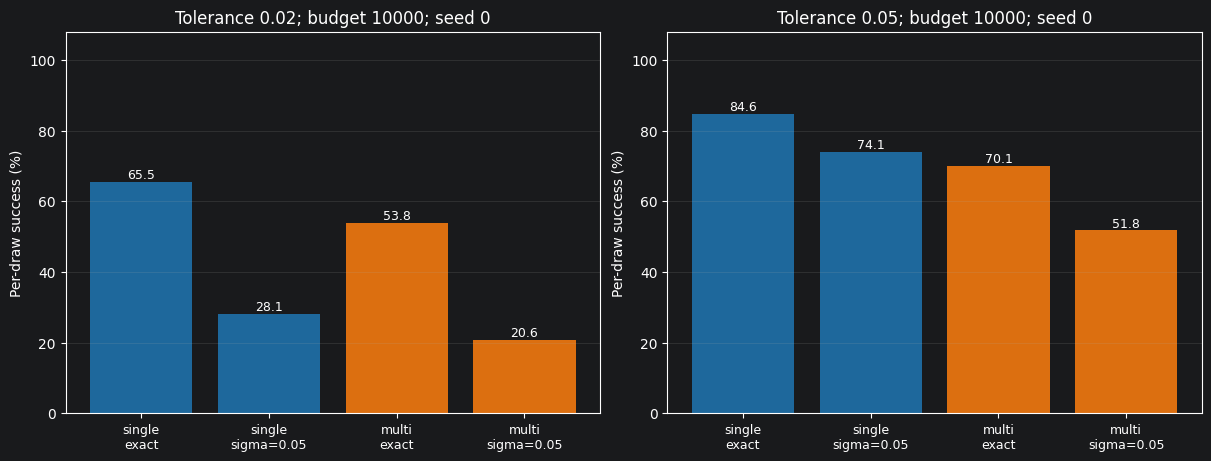

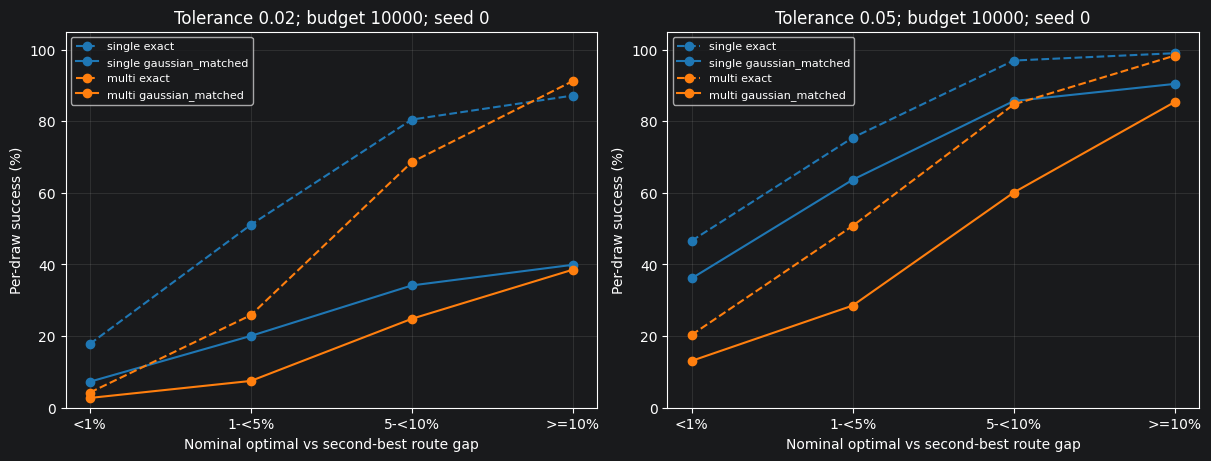

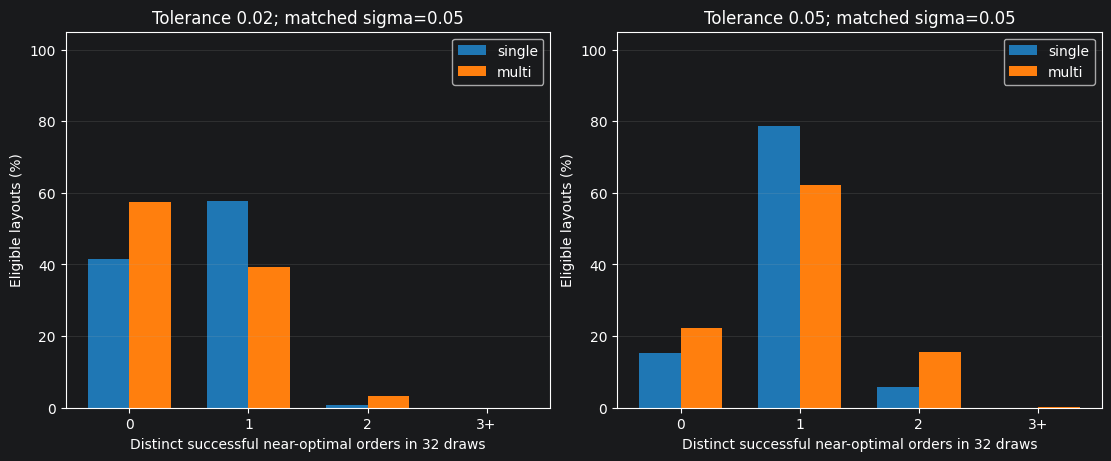

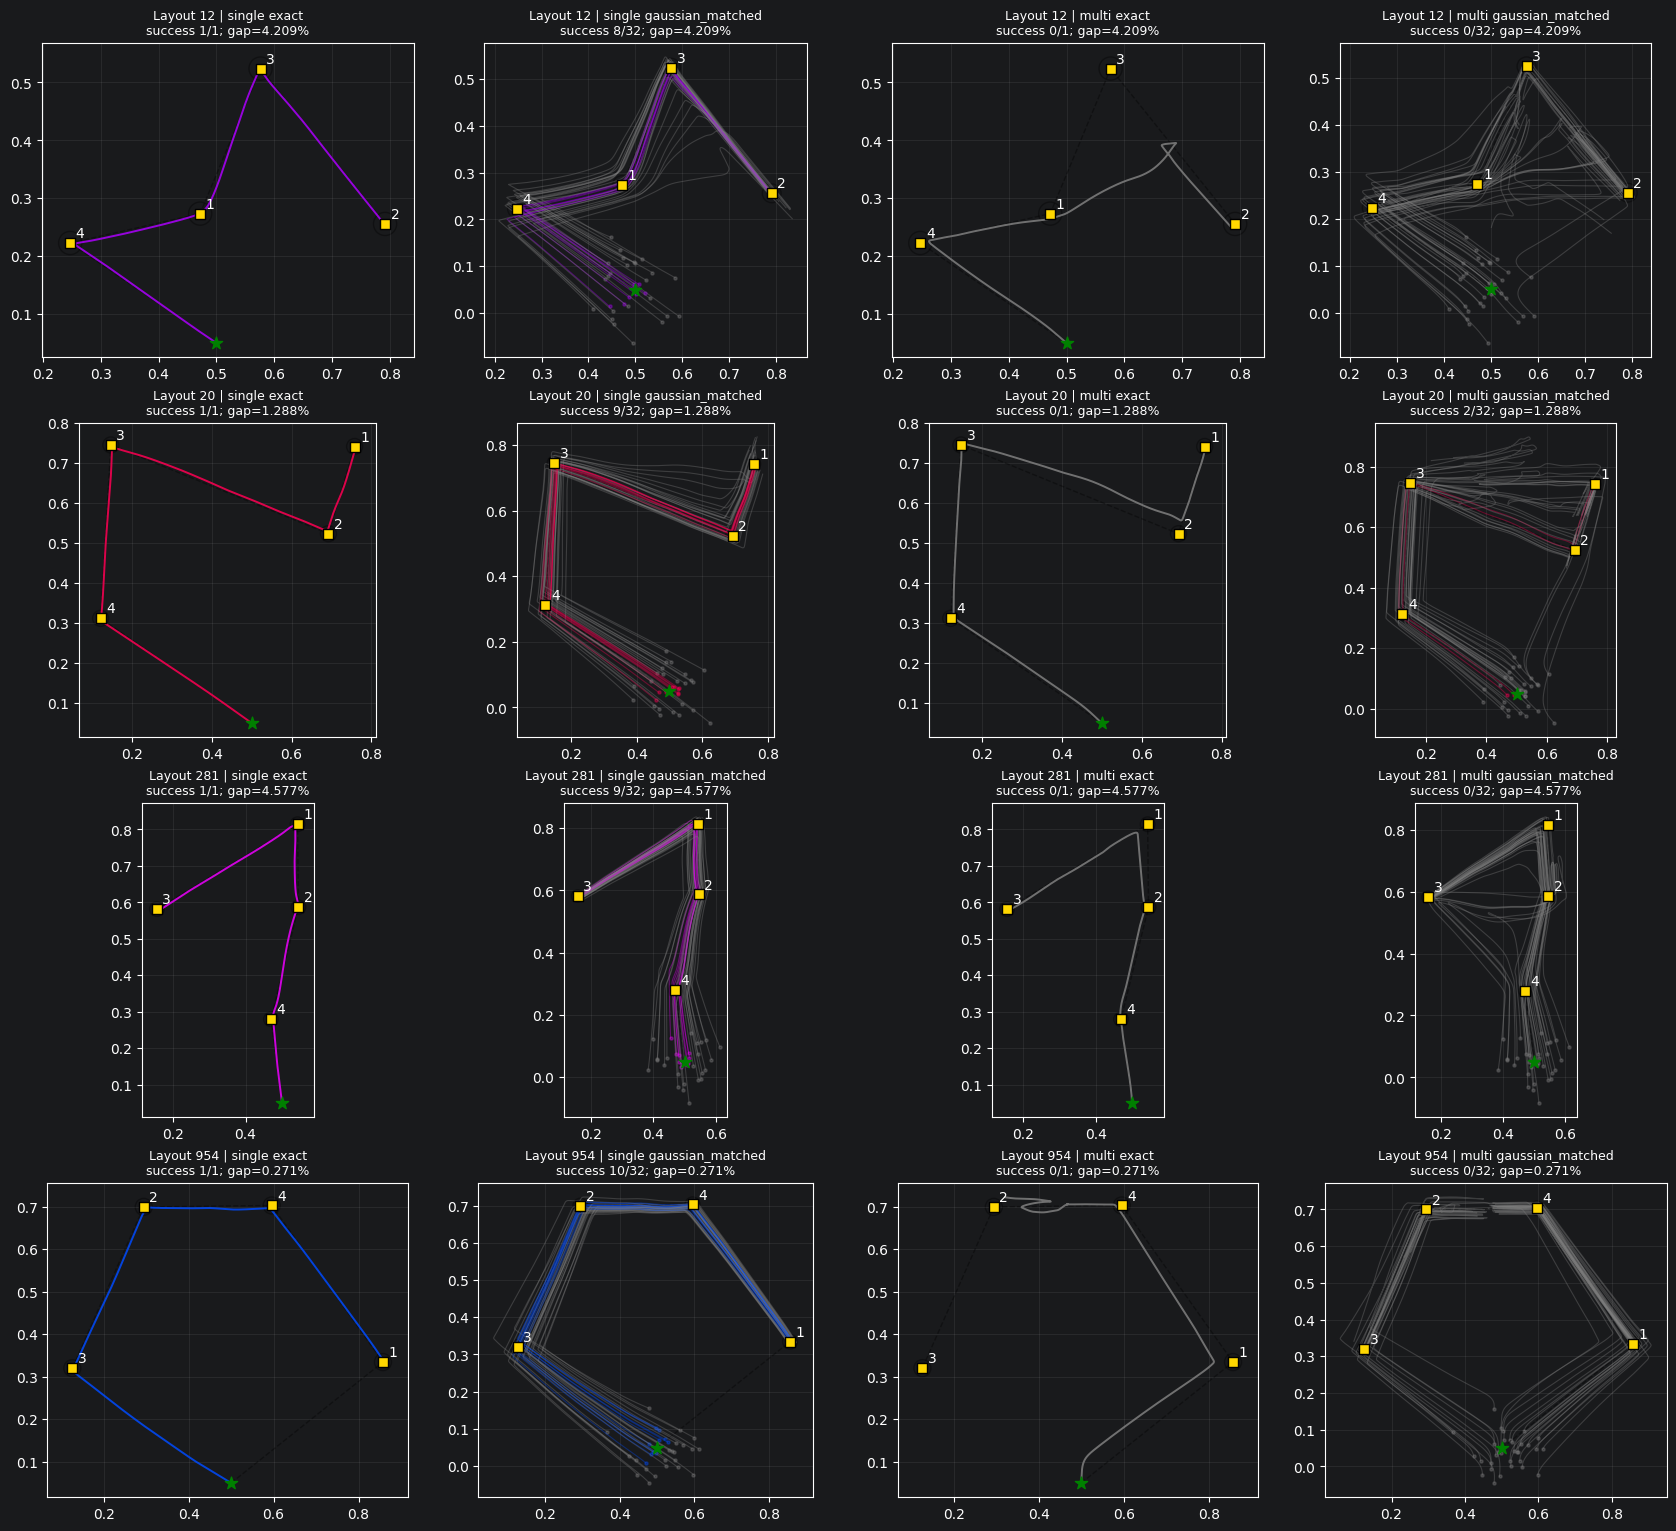

Finished. Primary table: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/evaluations/start_noise_sampling_v1/reports/1df64eb485b7ba30/sampling_summary.csv
Send back: /home/matcho/projects/streaming-flow-policy/experiments/four_boxes_experiments/four_targets/evaluations/start_noise_sampling_v1/reports/1df64eb485b7ba30/results_to_share.zip
Noisy initialization changes the first generated position. Connector metrics are auxiliary only.


In [7]:
COLORS = {'single':'tab:blue','multi':'tab:orange'}
LINE_STYLES = ['--','-',':','-.']
for budget in BUDGETS:
    sub = summary[(summary.budget==budget)&(summary.seed==PLOT_SEED)]
    fig,axes = plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
    for ax,tol in zip(axes,[0.02,0.05]):
        rows = sub[(sub.gap_bin=='ALL')&(sub.tolerance==tol)]
        labels = []; values = []; colors = []
        for mode in MODES:
            for name,sigma,k in INIT_CASES:
                row = rows[(rows['mode']==mode)&(rows.init_name==name)].iloc[0]
                labels.append(f'{mode}\n'+('exact' if sigma==0 else f'sigma={sigma:g}'))
                values.append(row.mean_success_percent); colors.append(COLORS[mode])
        bars = ax.bar(np.arange(len(values)),values,color=colors,alpha=.85)
        for bar,value in zip(bars,values):
            ax.text(bar.get_x()+bar.get_width()/2,value+1,f'{value:.1f}',ha='center',fontsize=9)
        ax.set_xticks(np.arange(len(values)),labels,fontsize=9); ax.set_ylim(0,108)
        ax.set_ylabel('Per-draw success (%)'); ax.set_title(f'Tolerance {tol}; budget {budget}; seed {PLOT_SEED}')
        ax.grid(axis='y',alpha=.2)
    fig.savefig(REPORT_DIR/f'success_sampling_{budget}.png',dpi=170); plt.show(); plt.close(fig)

    fig,axes = plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
    for ax,tol in zip(axes,[0.02,0.05]):
        for mode in MODES:
            for case_index,(name,sigma,k) in enumerate(INIT_CASES):
                g = sub[(sub['mode']==mode)&(sub.init_name==name)&(sub.tolerance==tol)&(sub.gap_bin!='ALL')]
                ys = g.set_index('gap_bin').reindex(GAP_LABELS).mean_success_percent
                ax.plot(range(4),ys,marker='o',color=COLORS[mode],
                        linestyle=LINE_STYLES[case_index%len(LINE_STYLES)],label=f'{mode} {name}')
        ax.set_xticks(range(4),GAP_LABELS); ax.set_ylim(0,105); ax.grid(alpha=.2)
        ax.set_xlabel('Nominal optimal vs second-best route gap'); ax.set_ylabel('Per-draw success (%)')
        ax.set_title(f'Tolerance {tol}; budget {budget}; seed {PLOT_SEED}'); ax.legend(fontsize=8)
    fig.savefig(REPORT_DIR/f'gap_sampling_{budget}.png',dpi=170); plt.show(); plt.close(fig)

    fig,axes = plt.subplots(1,2,figsize=(11,4.5),constrained_layout=True)
    for ax,tol in zip(axes,[0.02,0.05]):
        for mi,mode in enumerate(MODES):
            g = per_layout[(per_layout.budget==budget)&(per_layout.seed==PLOT_SEED)&
                (per_layout['mode']==mode)&(per_layout.init_name=='gaussian_matched')&
                (per_layout.tolerance==tol)&(per_layout.available_nearopt_center_orders>=2)]
            bins = np.minimum(g.n_nearopt_orders.to_numpy(dtype=int),3)
            frequencies = np.bincount(bins,minlength=4)/len(g)*100 if len(g) else np.zeros(4)
            ax.bar(np.arange(4)+(mi-.5)*.35,frequencies,width=.35,color=COLORS[mode],label=mode)
        ax.set_xticks(range(4),['0','1','2','3+']); ax.set_ylim(0,105); ax.grid(axis='y',alpha=.2)
        ax.set_xlabel(f'Distinct successful near-optimal orders in {NUM_NOISE_SAMPLES} draws')
        ax.set_ylabel('Eligible layouts (%)'); ax.set_title(f'Tolerance {tol}; matched sigma={MATCHED_SIGMA:g}')
        ax.legend()
    fig.savefig(REPORT_DIR/f'valid_order_diversity_{budget}.png',dpi=170); plt.show(); plt.close(fig)

    if PLOT_IDS:
        columns = [('single','exact'),('single','gaussian_matched'),('multi','exact'),('multi','gaussian_matched')]
        fig,axes = plt.subplots(len(PLOT_IDS),4,figsize=(17,3.8*len(PLOT_IDS)),squeeze=False,constrained_layout=True)
        lookup = rollouts[(rollouts.budget==budget)&(rollouts.seed==PLOT_SEED)&(rollouts.tolerance==.02)]
        lookup = lookup.set_index(['mode','init_name','layout_index','draw_id'])
        for row,i in enumerate(PLOT_IDS):
            targets = VAL['targets'][i]; start = VAL['starts'][i]
            for col,(mode,name) in enumerate(columns):
                ax = axes[row,col]; k = 1 if name=='exact' else NUM_NOISE_SAMPLES; passed = 0
                ax.plot(VAL['routes'][i,:,0],VAL['routes'][i,:,1],'--',color='black',alpha=.35,lw=1)
                for draw in range(k):
                    path = PLOT_PATHS[(budget,PLOT_SEED,mode,name,i,draw)]
                    info = lookup.loc[(mode,name,i,draw)]; passed += int(info.success)
                    color = plt.get_cmap('hsv')(int(info.order_class)/24) if info.order_evaluable else 'gray'
                    if np.isfinite(path).all():
                        ax.plot(path[:,0],path[:,1],color=color,alpha=.85 if k==1 else .35,lw=1.4 if k==1 else .8)
                        if name!='exact':
                            ax.scatter(path[0,0],path[0,1],s=5,color=color,alpha=.35)
                ax.scatter(*start,marker='*',color='green',s=85,zorder=5)
                ax.scatter(targets[:,0],targets[:,1],marker='s',color='gold',edgecolors='black',s=50,zorder=5)
                for j,target in enumerate(targets):
                    ax.add_patch(plt.Circle(target,.02,fill=False,color='black',alpha=.35))
                    ax.annotate(str(j+1),target,xytext=(4,4),textcoords='offset points')
                ax.set_title(f'Layout {i} | {mode} {name}\nsuccess {passed}/{k}; gap={GAPS[i]:.3f}%',fontsize=9)
                ax.set_aspect('equal',adjustable='box'); ax.grid(alpha=.15)
        fig.savefig(REPORT_DIR/f'fixed_paths_noise_{budget}_seed_{PLOT_SEED}.png',dpi=170)
        plt.show(); plt.close(fig)

archive = REPORT_DIR/'results_to_share.zip'
tmp_archive = archive.with_name(archive.name+'.tmp')
with zipfile.ZipFile(tmp_archive,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for p in sorted(REPORT_DIR.iterdir()):
        if p.suffix in {'.csv','.png','.json'}:
            z.write(p,arcname=p.name)
os.replace(tmp_archive,archive)
print('Finished. Primary table:', REPORT_DIR/'sampling_summary.csv')
print('Send back:', archive)
print('Noisy initialization changes the first generated position. Connector metrics are auxiliary only.')


## Reading the results

1. 先比较 sampling_summary.csv 的 mean_success_percent，尤其 gap <1% 和 1–<5%。
2. 看 single/multi 在相同 K 下的近优顺序多样性，以及这些顺序出现的次数。
   原始分支频率没有必要是均匀的；只看是否出现不同顺序还不足以证明正确建模了完整分布。
3. 用 paired_comparisons.csv 查看：噪声是否修复了精确起点失败，也是否损害原本成功的布局。
4. any_success_percent 只表示 K 次至少成功一次；本实验没有部署“试 K 次挑最好”的策略。
5. 轨迹更分散但单次成功率不提高，说明“有随机性”还没有解决全目标覆盖问题；
   如果多样性和单次成功率一起提高，才支持重新解释之前固定起点下的 multi 结果。

默认数据与旧的 10,000 epoch single/multi checkpoint 配套。不要把它与 1,000 epoch 的
选择器实验直接当作等预算比较。更改预算只会寻找该预算已有权重，不会自动训练。
仅作了代码静态检查；本 notebook 的模型加载、推理和绘图由你在本地执行。
